# 02 — Exploratory Data Analysis

**Objective:** Plan reproducible exploratory analysis after the data audit.  
**Owner:** TBD  
**Sprint:** TBD  

> Leakage warning: exploration must not use held-out test information to guide modeling.

In [1]:
from sklearn.datasets import fetch_openml

X, y = fetch_openml(data_id=45566, as_frame=True, return_X_y=True)

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (200000, 200)
y shape: (200000,)


In [ ]:
from pathlib import Path

project_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / "configs" / "config.yaml").is_file())
import sys
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))
from src.config import load_config

config = load_config()
print(config["project"]["name"])
print(config["project"]["random_state"])

In [2]:
# Show the first 5 rows of the dataset
display(X.head())

# Check the data types of the features
print("Data types:")
print(X.dtypes.value_counts())

# Check for missing values
print("\nTotal missing values:")
print(X.isnull().sum().sum())

# Check the class balance of the target
print("\nTarget distribution:")
print(y.value_counts())

print("\nTarget percentages:")
print(y.value_counts(normalize=True) * 100)

,var_0,var_1,var_2,var_3,var_4,var_5,var_6,var_7,var_8,var_9,...,var_190,var_191,var_192,var_193,var_194,var_195,var_196,var_197,var_198,var_199
0,8.9255,-6.7863,11.9081,5.0930,11.4607,-9.2834,5.1187,18.6266,-4.9200,5.7470,...,4.4354,3.9642,3.1364,1.6910,18.5227,-2.3978,7.8784,8.5635,12.7803,-1.0914
1,11.5006,-4.1473,13.8588,5.3890,12.3622,7.0433,5.6208,16.5338,3.1468,8.0851,...,7.6421,7.7214,2.5837,10.9516,15.4305,2.0339,8.1267,8.7889,18.3560,1.9518
2,8.6093,-2.7457,12.0805,7.8928,10.5825,-9.0837,6.9427,14.6155,-4.9193,5.9525,...,2.9057,9.7905,1.6704,1.6858,21.6042,3.1417,-6.5213,8.2675,14.7222,0.3965
3,11.0604,-2.1518,8.9522,7.1957,12.5846,-1.8361,5.8428,14.9250,-5.8609,8.2450,...,4.4666,4.7433,0.7178,1.4214,23.0347,-1.2706,-2.9275,10.2922,17.9697,-8.9996
4,9.8369,-1.4834,12.8746,6.6375,12.2772,2.4486,5.9405,19.2514,6.2654,7.6784,...,-1.4905,9.5214,-0.1508,9.1942,13.2876,-1.5121,3.9267,9.5031,17.9974,-8.8104


Data types:
float64    200
Name: count, dtype: int64

Total missing values:
0

Target distribution:
target
False    179902
True      20098
Name: count, dtype: int64

Target percentages:
target
False    89.951
True     10.049
Name: proportion, dtype: float64


## Planned work

Later: examine verified feature distributions, relationships, anomalies, and class balance, then export traceable figures and tables.

,count,mean,std,min,25%,50%,75%,max
var_0,200000.0,10.679914,3.040051,0.4084,8.453850,10.52475,12.758200,20.3150
var_1,200000.0,-1.627622,4.050044,-15.0434,-4.740025,-1.60805,1.358625,10.3768
var_2,200000.0,10.715192,2.640894,2.1171,8.722475,10.58000,12.516700,19.3530
var_3,200000.0,6.796529,2.043319,-0.0402,5.254075,6.82500,8.324100,13.1883
var_4,200000.0,11.078333,1.623150,5.0748,9.883175,11.10825,12.261125,16.6714
...,...,...,...,...,...,...,...,...
var_195,200000.0,-0.142088,1.429372,-5.2610,-1.170700,-0.17270,0.829600,4.2729
var_196,200000.0,2.303335,5.454369,-14.2096,-1.946925,2.40890,6.556725,18.3215
var_197,200000.0,8.908158,0.921625,5.9606,8.252800,8.88820,9.593300,12.0004
var_198,200000.0,15.870720,3.010945,6.2993,13.829700,15.93405,18.064725,26.0791


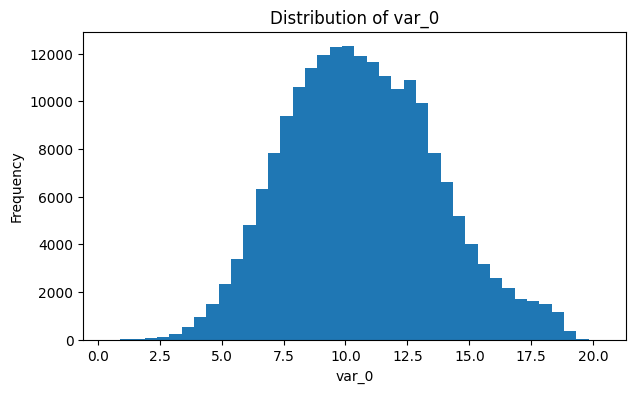

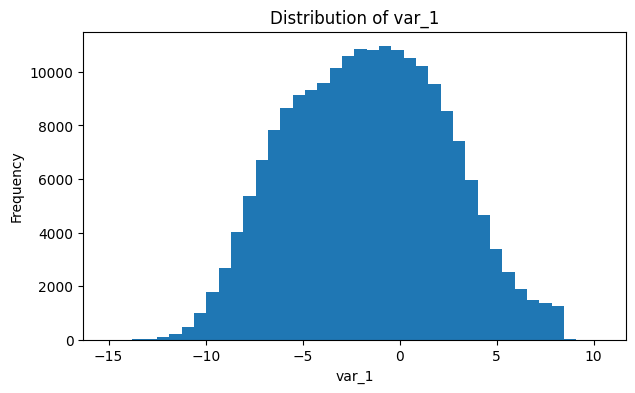

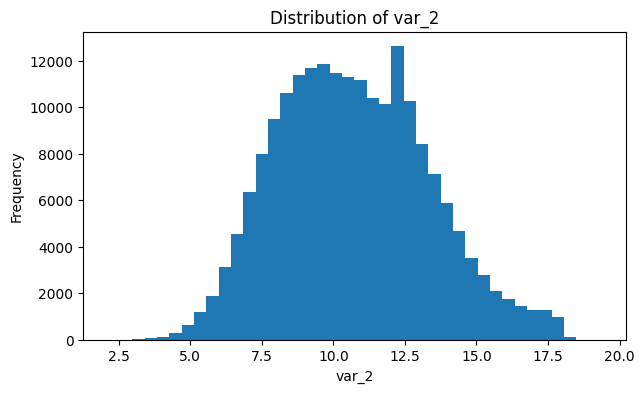

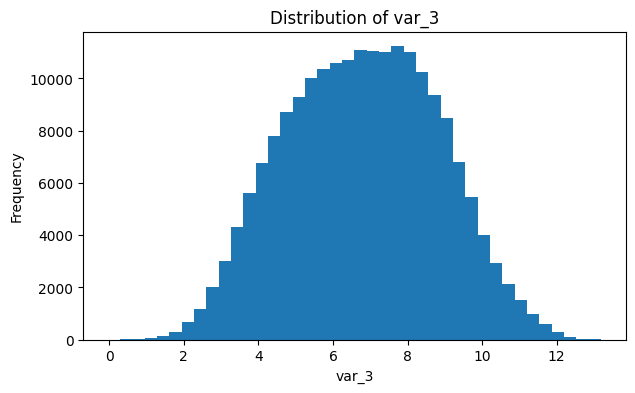

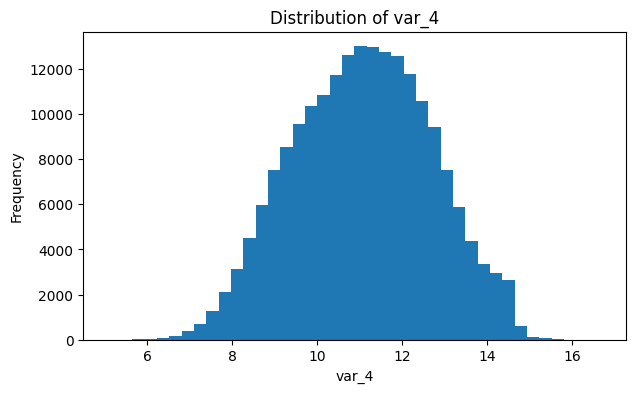

In [3]:
import matplotlib.pyplot as plt

# Summary statistics for all numerical features
display(X.describe().T)

# Plot distributions of a few representative features
features_to_plot = ["var_0", "var_1", "var_2", "var_3", "var_4"]

for feature in features_to_plot:
    plt.figure(figsize=(7, 4))
    plt.hist(X[feature], bins=40)
    plt.title(f"Distribution of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")
    plt.show()

In [5]:
# Create a dataframe for EDA
eda_df = X.copy()

# Convert target False/True to 0/1
eda_df["target"] = y.astype(str).map({
    "False": 0,
    "True": 1
}).values

# Compare feature means between the two target classes
class_means = eda_df.groupby("target").mean().T

class_means.columns = ["target_0_mean", "target_1_mean"]

class_means["absolute_difference"] = (
    class_means["target_1_mean"] - class_means["target_0_mean"]
).abs()

class_means = class_means.sort_values(
    "absolute_difference",
    ascending=False
)

display(class_means.head(15))

,target_0_mean,target_1_mean,absolute_difference
var_139,7.950512,6.056607,1.893905
var_76,6.215158,4.580307,1.634850
var_149,5.460487,3.825995,1.634492
var_21,17.418103,15.823715,1.594388
var_184,12.606196,14.103659,1.497462
var_174,20.357774,18.893971,1.463803
var_45,-12.556114,-13.984647,1.428533
var_80,5.938240,4.513254,1.424987
var_40,-6.862568,-5.498624,1.363944
var_90,-16.677375,-15.391398,1.285977


In [6]:
# Standardize the mean difference by the feature standard deviation
standardized_diff = (
    (class_means["target_1_mean"] - class_means["target_0_mean"]).abs()
    / X.std()
)

standardized_diff = standardized_diff.sort_values(ascending=False)

display(standardized_diff.head(15))

,0
var_81,0.269139
var_139,0.246396
var_12,0.231128
var_6,0.221953
var_110,0.213786
var_146,0.211686
var_53,0.210870
var_26,0.207622
var_76,0.205943
var_174,0.205117


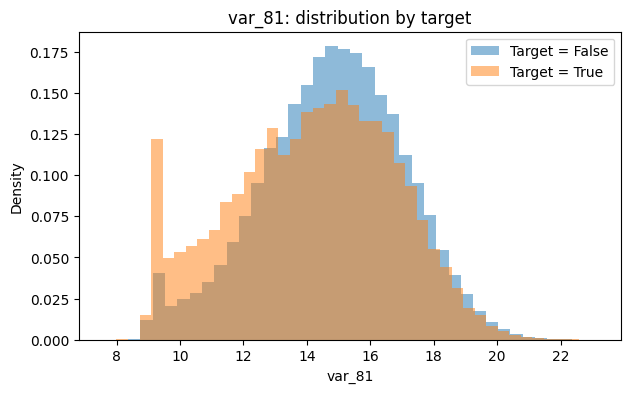

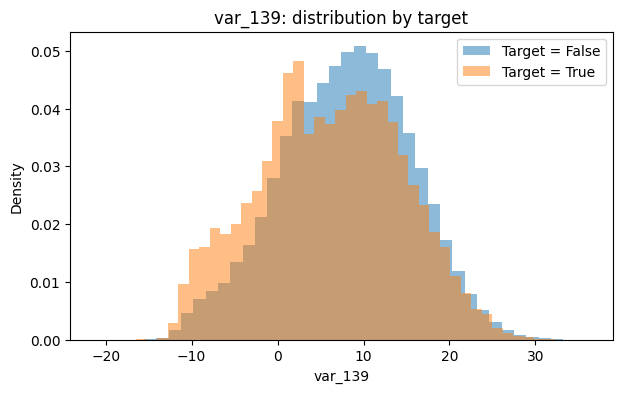

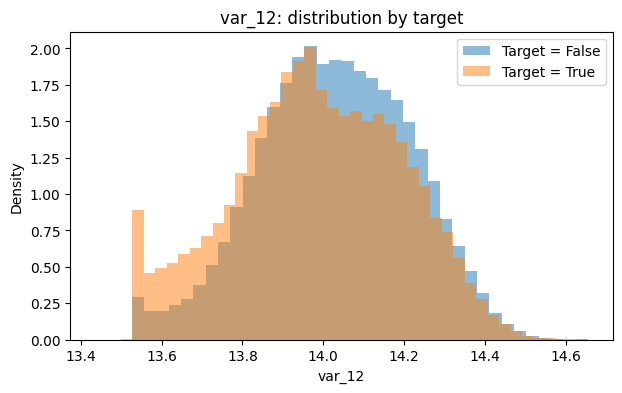

In [7]:
top_features = standardized_diff.head(3).index

for feature in top_features:
    plt.figure(figsize=(7, 4))

    plt.hist(
        X.loc[y.astype(str) == "False", feature],
        bins=40,
        alpha=0.5,
        label="Target = False",
        density=True
    )

    plt.hist(
        X.loc[y.astype(str) == "True", feature],
        bins=40,
        alpha=0.5,
        label="Target = True",
        density=True
    )

    plt.title(f"{feature}: distribution by target")
    plt.xlabel(feature)
    plt.ylabel("Density")
    plt.legend()
    plt.show()

In [8]:
import numpy as np

# Correlation between features
corr = X.corr()

corr_pairs = (
    corr.where(~np.eye(corr.shape[0], dtype=bool))
        .stack()
        .abs()
        .sort_values(ascending=False)
)

display(corr_pairs.head(20))

var_26   var_139    0.009844
var_139  var_26     0.009844
var_148  var_53     0.009788
var_53   var_148    0.009788
var_165  var_81     0.009714
var_81   var_165    0.009714
         var_174    0.009490
var_174  var_81     0.009490
var_183  var_189    0.009359
var_189  var_183    0.009359
var_169  var_146    0.009071
var_146  var_169    0.009071
var_6    var_80     0.008958
var_80   var_6      0.008958
var_132  var_122    0.008956
var_122  var_132    0.008956
var_81   var_172    0.008936
var_172  var_81     0.008936
var_80   var_1      0.008855
var_1    var_80     0.008855
dtype: float64

In [9]:
# Check potential outliers using the IQR method

Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

outliers = ((X < (Q1 - 1.5 * IQR)) |
            (X > (Q3 + 1.5 * IQR))).sum()

outlier_summary = outliers.sort_values(ascending=False)

print("Features with the most potential outliers:")
display(outlier_summary.head(20))

Features with the most potential outliers:


,0
var_179,1509
var_44,1208
var_93,889
var_146,804
var_192,733
var_31,637
var_133,589
var_105,572
var_38,502
var_124,498


## EDA Summary

- The dataset contains 200 numerical features.
- No missing values were detected.
- The target is imbalanced: approximately 90% False and 10% True.
- Feature-to-feature linear correlations are very weak.
- Some features show differences in their distributions between the two target classes.
- Potential outliers were detected in several features using the IQR method.
- Outliers are retained at this stage and should be handled carefully during modeling.